<a href="https://colab.research.google.com/github/tonycuenca99-hue/ARQUIVOS-IA/blob/main/DEEP%20LEARNING%201.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:

import pandas as pd
# Método para selecionar arquivo
    from tkinter import Tk
    from tkinter.filedialog import askopenfilename
    Tk().withdraw()  # Oculta a janela principal
    caminho_arquivo = askopenfilename(title="Selecione seu arquivo CSV")

# Carregar o CSV
df = pd.read_csv(caminho_arquivo)

print("\nPrimeiras linhas do dataset:")
print(df.head())
# DEFINIR FEATURES (X) E TARGET (y)

# Ajuste aqui os nomes das colunas dependendo do seu dataset
# Exemplo:
# X = df.drop("target", axis=1).values
# y = df["target"].values

# ❗❗ IMPORTANTE: EDITE AQUI PARA SEU PROJETO ❗❗
coluna_target = "coluna_target_aqui"   # <-- troque para sua coluna real

X = df.drop(columns=[coluna_target]).values
y = df[coluna_target].values

print("\nFormato dos dados:")
print("X:", X.shape)
print("y:", y.shape)


import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint


#SEPARAÇÃO DOS DADOS
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ESCALONAMENTO
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

early_stop = EarlyStopping(monitor='val_loss', patience=30, restore_best_weights=True)
lr_reduce = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=1e-6)

checkpoint = ModelCheckpoint(
    'melhor_modelo.h5',
    monitor='val_loss',
    save_best_only=True
)

# FUNÇÃO PARA TREINAR MODELOS
def treinar_modelo(modelo, nome):
    history = modelo.fit(
        X_train_scaled, y_train,
        validation_split=0.1,
        epochs=300,
        batch_size=32,
        callbacks=[early_stop, lr_reduce, checkpoint],
        verbose=0
    )
    y_pred = modelo.predict(X_test_scaled).flatten()

    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)

    print(f"\n→ {nome} | R²={r2:.6f}  RMSE={rmse:.6f}  MAE={mae:.6f}")

    return {"nome": nome, "modelo": modelo, "history": history,
            "r2": r2, "rmse": rmse, "mae": mae, "y_pred": y_pred}

# modelo 1 – MLP Simples
modelo1 = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1)
])

modelo1.compile(optimizer=Adam(0.001), loss='mse')
resultado1 = treinar_modelo(modelo1, "MLP Simples")


# modelo 2 – REDE PROFUNDA
modelo2 = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1)
])

modelo2.compile(optimizer=Adam(0.001), loss='mse')
resultado2 = treinar_modelo(modelo2, "Rede Profunda (DNN)")

# modelo 3 – DNN + Dropout + BatchNorm
modelo3 = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    BatchNormalization(),
    Dropout(0.2),

    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),

    Dense(32, activation='relu'),
    Dense(1)
])

modelo3.compile(optimizer=Adam(0.001), loss='mse')
resultado3 = treinar_modelo(modelo3, "DNN + Dropout + BatchNorm")



# TABELA COMPARATIVA
df_resultados = pd.DataFrame([
    {"Modelo": r["nome"], "R²": r["r2"], "RMSE": r["rmse"], "MAE": r["mae"]}
    for r in [resultado1, resultado2, resultado3]
])

print("\n==================== RESULTADOS ====================")
print(df_resultados)

IndentationError: unexpected indent (ipython-input-3039237289.py, line 3)

Por favor, faça o upload do seu arquivo CSV.


Saving 01-04T184148_000_mode1.csv to 01-04T184148_000_mode1 (1).csv
Arquivo carregado: "01-04T184148_000_mode1 (1).csv" (218050 bytes)

Primeiras linhas do dataset:
   timestamp  pCut::Motor_Torque  pCut::CTRL_Position_controller::Lag_error  \
0      0.008            0.199603                                   0.027420   
1      0.012            0.281624                                   0.002502   
2      0.016            0.349315                                  -0.018085   
3      0.020            0.444450                                  -0.054680   
4      0.024            0.480923                                  -0.042770   

   pCut::CTRL_Position_controller::Actual_position  \
0                                        628392628   
1                                        628392625   
2                                        628392621   
3                                        628392617   
4                                        628392613   

   pCut::CTRL_Position_controller::

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


→ MLP Simples | R²=0.995178  RMSE=4.951774  MAE=2.458478

Treinando modelo: Rede Profunda (DNN)
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
→ Rede Profunda (DNN) | R²=0.979959  RMSE=10.095140  MAE=5.097472

Treinando modelo: DNN + Dropout + BatchNorm


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
→ DNN + Dropout + BatchNorm | R²=-0.262043  RMSE=80.111051  MAE=21.267585

=RESULTADOS
                      Modelo        R²       RMSE        MAE
0                MLP Simples  0.995178   4.951774   2.458478
1        Rede Profunda (DNN)  0.979959  10.095140   5.097472
2  DNN + Dropout + BatchNorm -0.262043  80.111051  21.267585


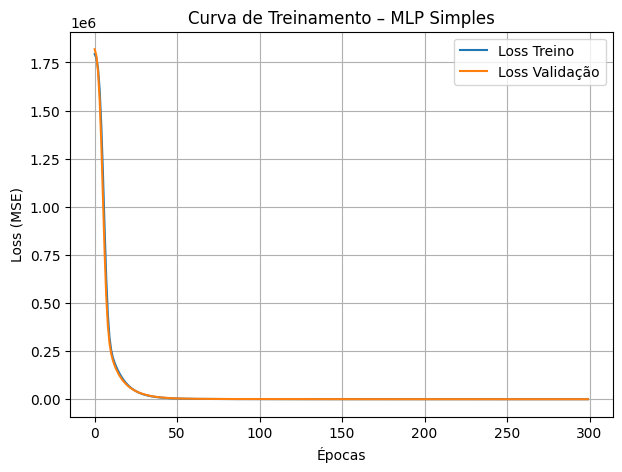

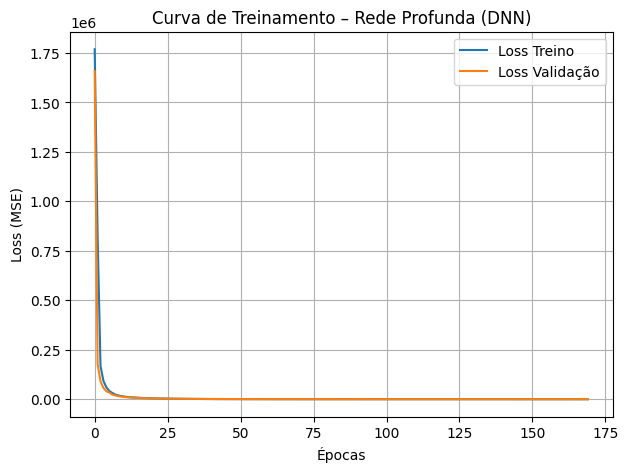

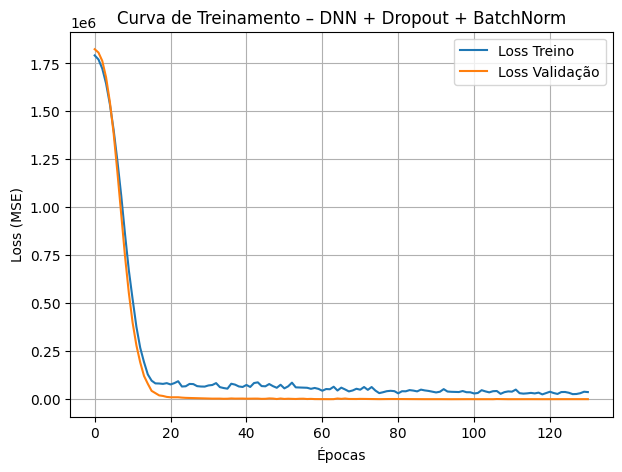

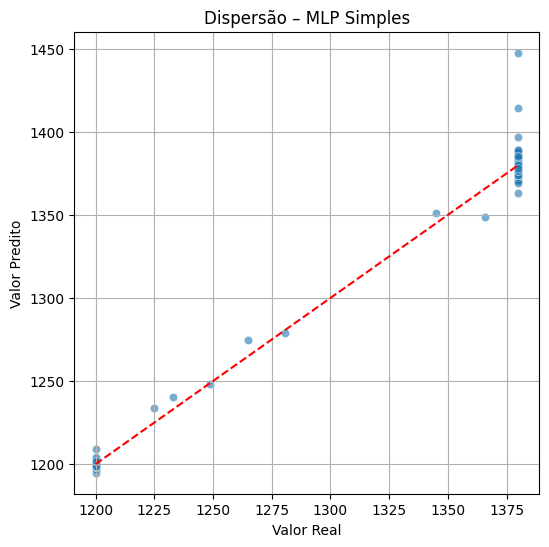

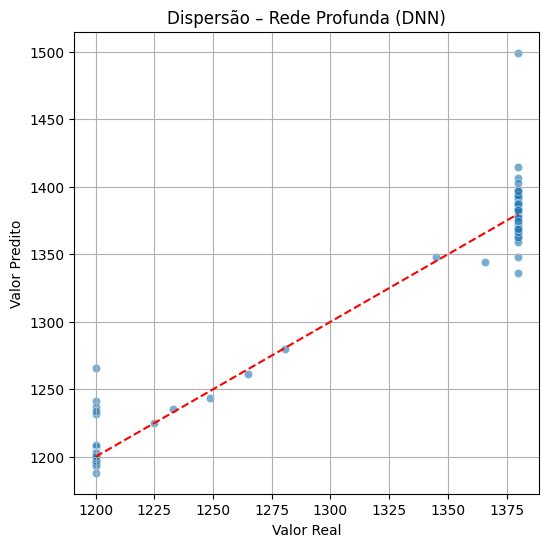

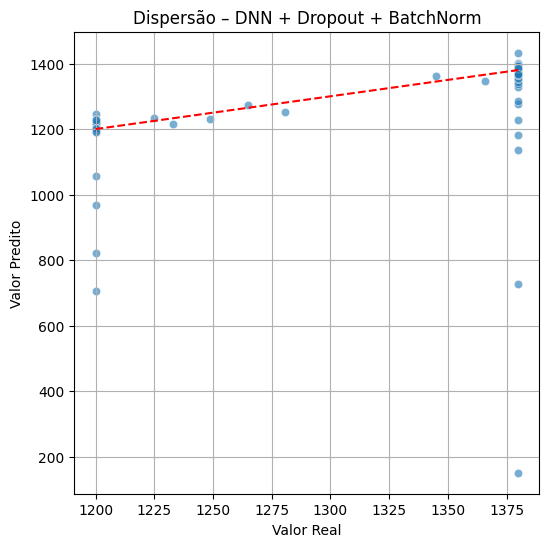

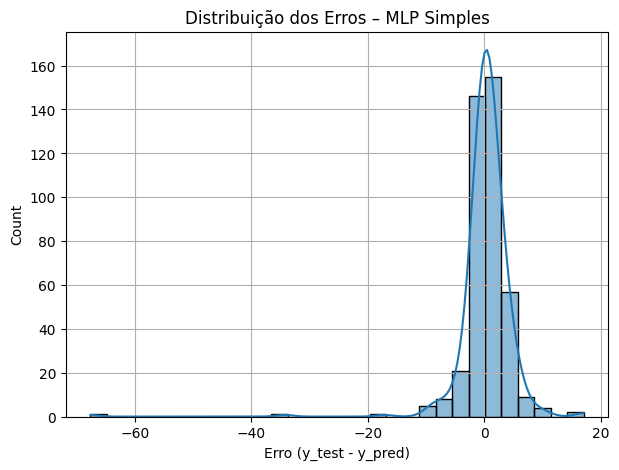

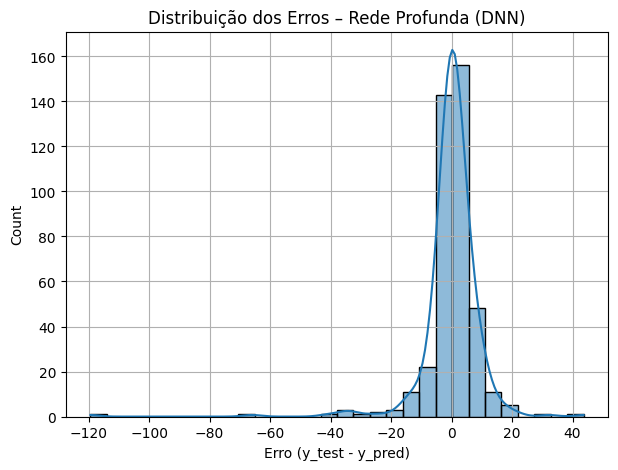

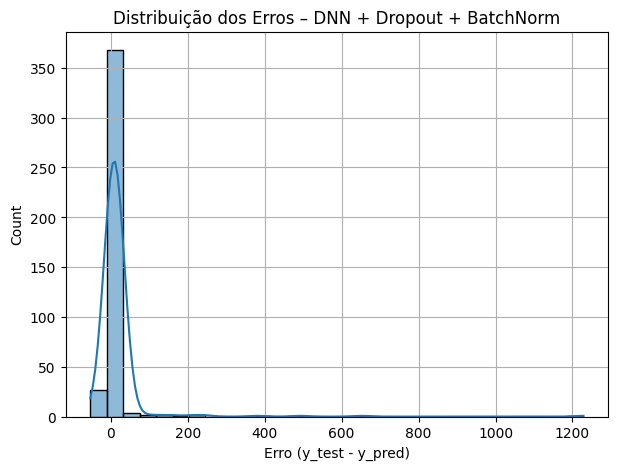


Arquivo 'resultados_deep_learning.csv' salvo com sucesso!


In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Importar módulo de arquivos do Google Colab
from google.colab import files
import io # Importar io para ler bytes

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# --- CARREGAR DADOS COM UPLOAD DE ARQUIVO (COMPATÍVEL COM COLAB) ---
print("Por favor, faça o upload do seu arquivo CSV.")
uploaded = files.upload()

# Ler o arquivo carregado
for fn in uploaded.keys():
  print('Arquivo carregado: "{name}" ({length} bytes)'.format(
      name=fn, length=len(uploaded[fn])))
  caminho_arquivo = fn # O nome do arquivo carregado

# Carregar o CSV usando pandas e io.BytesIO
df = pd.read_csv(io.BytesIO(uploaded[caminho_arquivo]))

print("\nPrimeiras linhas do dataset:")
print(df.head())

# DEFINIR FEATURES (X) E TARGET (y)
# ❗❗ IMPORTANTE: EDITE AQUI PARA SEU PROJETO ❗❗
coluna_target = "pSpintor::VAX_speed"   # <-- troque para sua coluna real

# Verifique se a coluna target existe no DataFrame
if coluna_target not in df.columns:
    print(f"Erro: A coluna target '{coluna_target}' não foi encontrada no seu dataset. Por favor, ajuste 'coluna_target' no código.")
    # Você pode optar por sair ou usar uma coluna padrão/primeira coluna como target temporário
    # Para este exemplo, vamos assumir que o usuário ajustará.
    raise ValueError(f"Coluna target '{coluna_target}' não encontrada.")

X = df.drop(columns=[coluna_target])
y = df[coluna_target]

print("Dados carregados. Formato de X:", X.shape, "Formato de y:", y.shape)

# SEPARAÇÃO DOS DADOS
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ESCALONAMENTO
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Formato do treino:", X_train_scaled.shape)
print("Formato do teste:", X_test_scaled.shape)

#  VERIFICAÇÃO
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=30,
    restore_best_weights=True
)

lr_reduce = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=10,
    min_lr=1e-6
)

checkpoint = ModelCheckpoint(
    'melhor_modelo.h5',
    monitor='val_loss',
    save_best_only=True
)

# FUNÇÃO PARA TREINAR E AVALIAR MODELOS

def treinar_modelo(modelo, nome):
    print(f"\nTreinando modelo: {nome}")

    history = modelo.fit(
        X_train_scaled, y_train,
        validation_split=0.1,
        epochs=300,
        batch_size=32,
        callbacks=[early_stop, lr_reduce, checkpoint],
        verbose=0
    )

    # PREDIÇÃO
    y_pred = modelo.predict(X_test_scaled).flatten()

    # MÉTRICAS
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)

    print(f"→ {nome} | R²={r2:.6f}  RMSE={rmse:.6f}  MAE={mae:.6f}")

    return {
        "nome": nome,
        "modelo": modelo,
        "history": history,
        "r2": r2,
        "rmse": rmse,
        "mae": mae,
        "y_pred": y_pred
    }



# MODELO 1 – MLP Simples
modelo1 = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1)
])

modelo1.compile(optimizer=Adam(0.001), loss='mse')

resultado1 = treinar_modelo(modelo1, "MLP Simples")

# MODELO 2 – REDE PROFUNDA (DEEP NEURAL NETWORK)
modelo2 = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1)
])

modelo2.compile(optimizer=Adam(0.001), loss='mse')

resultado2 = treinar_modelo(modelo2, "Rede Profunda (DNN)")

#MODELO 3 – REDE COM DROPOUT + BATCH NORMALIZATION
modelo3 = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    BatchNormalization(),
    Dropout(0.2),

    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),

    Dense(32, activation='relu'),
    Dense(1)
])

modelo3.compile(optimizer=Adam(0.001), loss='mse')

resultado3 = treinar_modelo(modelo3, "DNN + Dropout + BatchNorm")


#TABELA COMPARATIVA

df_resultados = pd.DataFrame([
    {
        "Modelo": r["nome"],
        "R²": r["r2"],
        "RMSE": r["rmse"],
        "MAE": r["mae"]
    }
    for r in [resultado1, resultado2, resultado3]
])

print("\n=RESULTADOS")
print(df_resultados)

# GRÁFICO DE CURVA DE TREINAMENTO
for r in [resultado1, resultado2, resultado3]:
    plt.figure(figsize=(7,5))
    plt.plot(r["history"].history['loss'], label='Loss Treino')
    plt.plot(r["history"].history['val_loss'], label='Loss Validação')
    plt.title(f"Curva de Treinamento – {r['nome']}")
    plt.xlabel("Épocas")
    plt.ylabel("Loss (MSE)")
    plt.legend()
    plt.grid()
    plt.show()

# GRÁFICO DE DISPERSÃO (Y verdadeiro vs Y predito)
for r in [resultado1, resultado2, resultado3]:
    plt.figure(figsize=(6,6))
    sns.scatterplot(x=y_test, y=r["y_pred"], alpha=0.6)
    plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--')
    plt.title(f"Dispersão – {r['nome']}")
    plt.xlabel("Valor Real")
    plt.ylabel("Valor Predito")
    plt.grid()
    plt.show()

# DISTRIBUIÇÃO DOS ERROS
for r in [resultado1, resultado2, resultado3]:
    erros = y_test - r["y_pred"]

    plt.figure(figsize=(7,5))
    sns.histplot(erros, bins=30, kde=True)
    plt.title(f"Distribuição dos Erros – {r['nome']}")
    plt.xlabel("Erro (y_test - y_pred)")
    plt.grid()
    plt.show()

# SALVAR TABELA EM CSV
df_resultados.to_csv("resultados_deep_learning.csv", index=False)
print("\nArquivo 'resultados_deep_learning.csv' salvo com sucesso!")

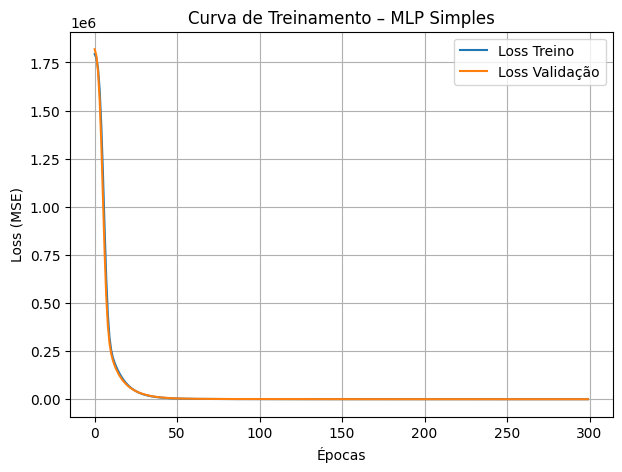

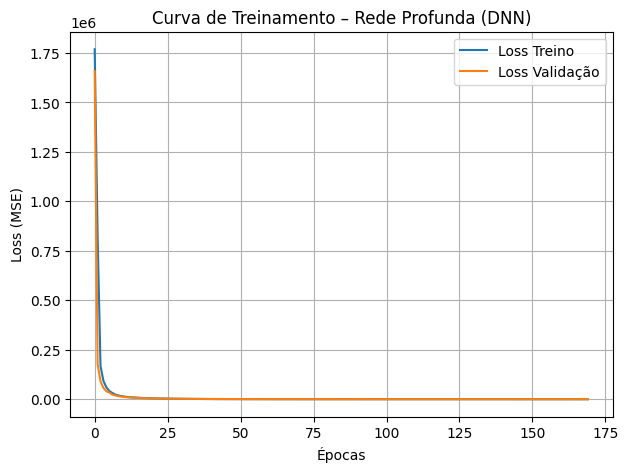

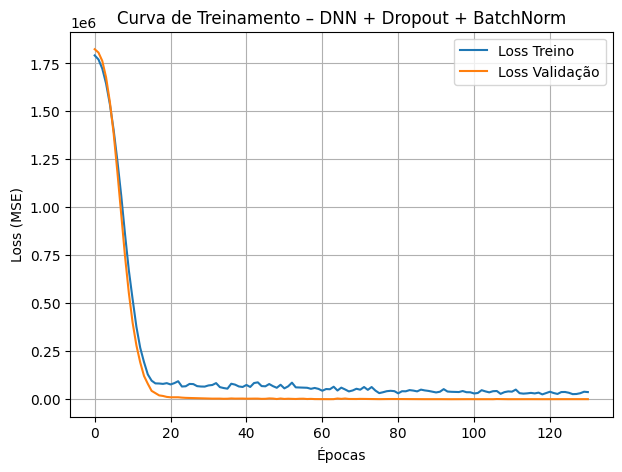

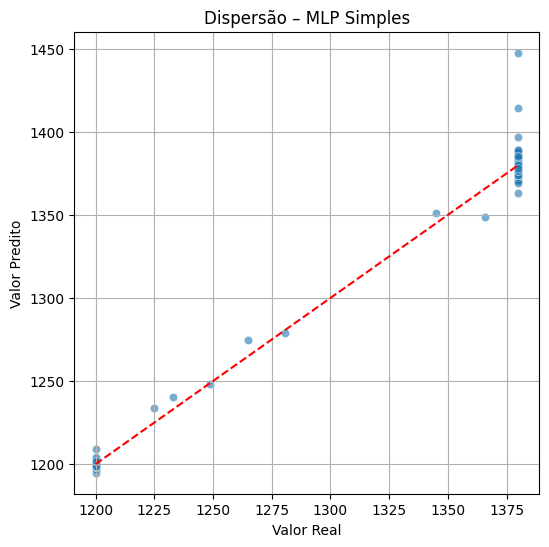

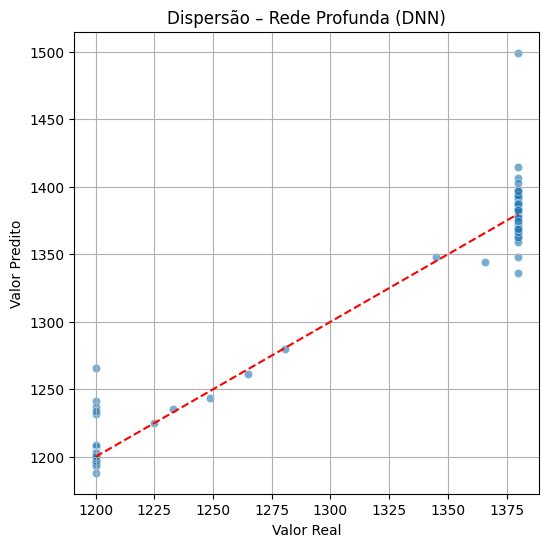

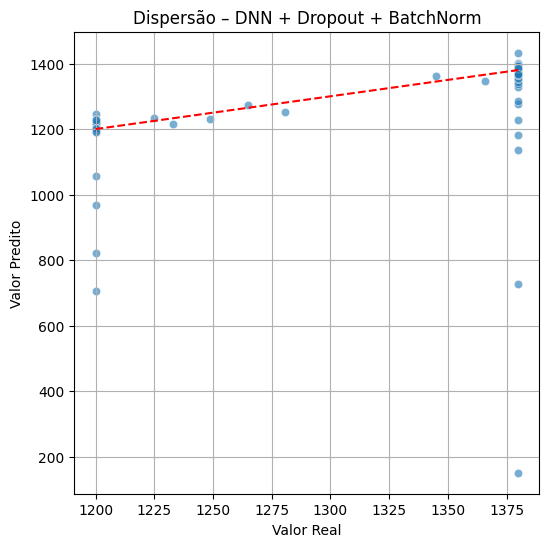

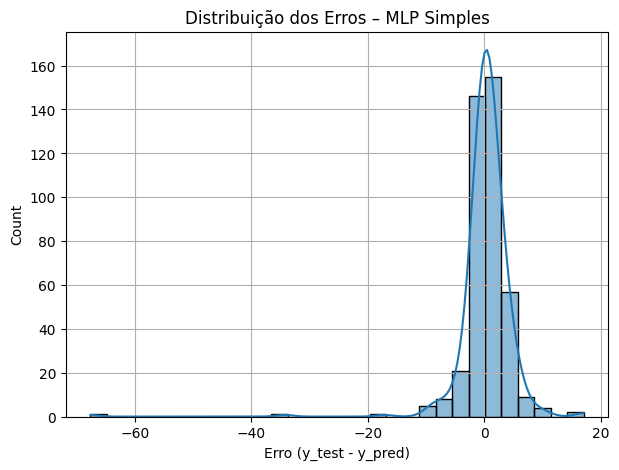

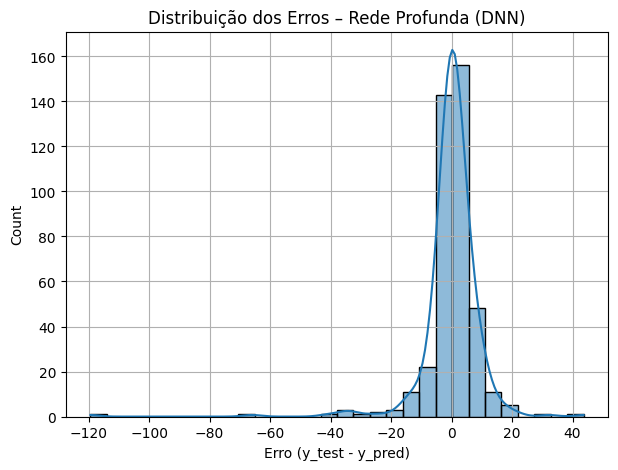

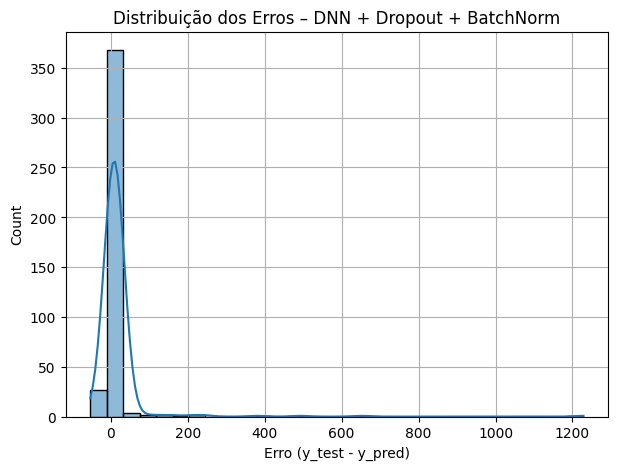


Arquivo 'resultados_deep_learning.csv' salvo com sucesso!


In [12]:
# 9. GRÁFICO DE CURVA DE TREINAMENTO
# ================================================================
for r in [resultado1, resultado2, resultado3]:
    plt.figure(figsize=(7,5))
    plt.plot(r["history"].history['loss'], label='Loss Treino')
    plt.plot(r["history"].history['val_loss'], label='Loss Validação')
    plt.title(f"Curva de Treinamento – {r['nome']}")
    plt.xlabel("Épocas")
    plt.ylabel("Loss (MSE)")
    plt.legend()
    plt.grid()
    plt.show()


# ================================================================
# 10. GRÁFICO DE DISPERSÃO (Y verdadeiro vs Y predito)
# ================================================================
for r in [resultado1, resultado2, resultado3]:
    plt.figure(figsize=(6,6))
    sns.scatterplot(x=y_test, y=r["y_pred"], alpha=0.6)
    plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--')
    plt.title(f"Dispersão – {r['nome']}")
    plt.xlabel("Valor Real")
    plt.ylabel("Valor Predito")
    plt.grid()
    plt.show()


# ================================================================
# 11. DISTRIBUIÇÃO DOS ERROS
# ================================================================
for r in [resultado1, resultado2, resultado3]:
    erros = y_test - r["y_pred"]

    plt.figure(figsize=(7,5))
    sns.histplot(erros, bins=30, kde=True)
    plt.title(f"Distribuição dos Erros – {r['nome']}")
    plt.xlabel("Erro (y_test - y_pred)")
    plt.grid()
    plt.show()


# ================================================================
# 12. SALVAR TABELA EM CSV
# ================================================================
df_resultados.to_csv("resultados_deep_learning.csv", index=False)
print("\nArquivo 'resultados_deep_learning.csv' salvo com sucesso!")

In [13]:
print("\n--- Métricas Detalhadas por Modelo ---")
for index, row in df_resultados.iterrows():
    print(f"\nModelo: {row['Modelo']}")
    print(f"  R²: {row['R²']:.6f}")
    print(f"  RMSE: {row['RMSE']:.6f}")
    print(f"  MAE: {row['MAE']:.6f}")
    # Calculando e mostrando o MSE
    mse = row['RMSE']**2
    print(f"  MSE: {mse:.6f}")
print("------------------------------------")


--- Métricas Detalhadas por Modelo ---

Modelo: MLP Simples
  R²: 0.995178
  RMSE: 4.951774
  MAE: 2.458478
  MSE: 24.520065

Modelo: Rede Profunda (DNN)
  R²: 0.979959
  RMSE: 10.095140
  MAE: 5.097472
  MSE: 101.911861

Modelo: DNN + Dropout + BatchNorm
  R²: -0.262043
  RMSE: 80.111051
  MAE: 21.267585
  MSE: 6417.780518
------------------------------------
